<a href="https://colab.research.google.com/github/rka0285058-afk/Artificial-Intelligence/blob/main/Copy_of_Bio_Gas_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15298 entries, 0 to 15297
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     15298 non-null  int64  
 1   Month                    15298 non-null  int64  
 2   Day                      15298 non-null  int64  
 3   Pig Manure (kg)          15298 non-null  float64
 4   Kitchen Food Waste (kg)  15298 non-null  float64
 5   Chicken Litter (kg)      15298 non-null  float64
 6   Cassava (kg)             15298 non-null  float64
 7   Bagasse Feed (kg)        15298 non-null  float64
 8   Energy Grass (kg)        15298 non-null  float64
 9   Banana Shafts (kg)       15298 non-null  float64
 10  Alcohol Waste (kg)       15298 non-null  float64
 11  Municipal Residue (kg)   15298 non-null  float64
 12  Fish Waste (kg)          15298 non-null  float64
 13  Water (L)                15298 non-null  float64
 14  Diesel

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Software/biogas_dataset.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded '{file_path}' into a DataFrame.")
display(df.head())

Successfully loaded '/content/drive/MyDrive/Software/biogas_dataset.csv' into a DataFrame.


,Year,Month,Day,Pig Manure (kg),Kitchen Food Waste (kg),Chicken Litter (kg),Cassava (kg),Bagasse Feed (kg),Energy Grass (kg),Banana Shafts (kg),...,Fish Waste (kg),Water (L),Diesel (L),Electricity Use (kWh),Temperature (C),Humidity (%),Rainfall (mm),C/N Ratio,Digester Temp (C),biogas_production
0,2010,1,1,14.785537,7.305310,13.050192,17.684926,14.830197,9.906063,7.743000,...,4.191195,82.619547,2.866209,25.258583,33.135037,75.997637,10.193971,26.666653,36.841906,58.956420
1,2010,1,1,15.254357,16.039052,12.686489,10.436417,17.292921,16.466707,5.785339,...,5.903021,107.321735,3.588735,34.322305,29.268128,76.987494,1.284466,23.100934,32.535921,71.951004
2,2010,1,1,35.566142,19.992287,8.336992,33.463391,15.889184,5.330412,9.085270,...,4.300494,138.387090,0.070003,18.190760,31.736523,81.425018,3.108892,21.273712,37.357393,102.965090
3,2010,1,2,34.496363,17.751484,8.232446,14.096671,14.088245,8.093446,11.882885,...,7.469573,99.479363,1.532482,44.195734,29.677593,85.800528,1.940286,31.250011,33.820132,83.783745
4,2010,1,2,21.187255,13.533476,14.489672,14.756190,12.165611,12.064431,4.597625,...,2.617079,86.328262,0.362056,30.257209,29.731208,73.236587,2.442031,20.177435,36.571963,70.489410


In [ ]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Year,Month,Day,Pig Manure (kg),Kitchen Food Waste (kg),...,Humidity (%),Rainfall (mm),C/N Ratio,Digester Temp (C),biogas_production
count,15298.000000,15298.000000,15298.000000,15298.000000,15298.000000,...,15298.000000,15298.000000,15298.000000,15298.000000,15298.000000
mean,2016.999477,6.521571,15.723101,25.097493,17.945933,...,74.992736,4.971381,25.001967,35.964293,79.211060
std,4.320433,3.448833,8.799470,9.869836,6.975865,...,10.052740,5.038343,2.985859,1.988999,11.257695
min,2010.000000,1.000000,1.000000,0.103366,0.002521,...,33.673346,0.000365,15.000000,30.000000,41.937317
25%,2013.000000,4.000000,8.000000,18.270828,13.181458,...,68.219267,1.426376,22.973213,34.645313,71.296262
50%,2017.000000,7.000000,16.000000,25.007929,17.880665,...,75.018625,3.433093,25.016368,35.970754,78.816460
75%,2021.000000,10.000000,23.000000,31.805712,22.611847,...,81.771895,6.840137,26.986567,37.313701,86.707223
max,2024.000000,12.000000,31.000000,60.711466,47.323544,...,111.650722,45.721461,36.192960,42.000000,121.740430


In [ ]:
print("\nMissing values per column:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    display(missing_values)
    print("\nHandling missing values: For simplicity, we will drop rows with any missing values. For a more robust approach, imputation strategies could be explored.")
    df_cleaned = df.dropna()
    print(f"Original rows: {len(df)}, Rows after dropping missing values: {len(df_cleaned)}")
else:
    print("No missing values found.")
    df_cleaned = df.copy()



Missing values per column:
No missing values found.


In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable
target_column = 'biogas_production'
y = df_cleaned[target_column]

# Define features (all columns except the target and potentially ID/time-based columns if not used as features)
# For this dataset, 'Year', 'Month', 'Day' can be kept as numerical features or engineered further if needed.
X = df_cleaned.drop(columns=[target_column])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Training features (X_train) shape: {X_train.shape}")
print(f"Testing features (X_test) shape: {X_test.shape}")


Features (X) shape: (15298, 21)
Target (y) shape: (15298,)
Training features (X_train) shape: (12238, 21)
Testing features (X_test) shape: (3060, 21)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train a RandomForestRegressor model
# RandomForest is chosen for its robustness and good performance on various datasets
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")


RandomForestRegressor model trained successfully.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")

# Optional: Display feature importances (useful for understanding the model)
print("\nFeature Importances:")
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(feature_importances.head(10)) # Display top 10 most important features


Model Performance on Test Set:
Mean Absolute Error (MAE): 2.605
Mean Squared Error (MSE): 11.027
Root Mean Squared Error (RMSE): 3.321
R-squared (R2): 0.911

Feature Importances:


,0
Pig Manure (kg),0.489467
Kitchen Food Waste (kg),0.158161
Cassava (kg),0.114685
Municipal Residue (kg),0.062605
Chicken Litter (kg),0.058314
Bagasse Feed (kg),0.038489
Water (L),0.011976
Temperature (C),0.011723
Energy Grass (kg),0.007169
Fish Waste (kg),0.006198


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Software/biogas_dataset.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded '{file_path}' into a DataFrame.")
display(df.head())

Successfully loaded '/content/drive/MyDrive/Software/biogas_dataset.csv' into a DataFrame.


,Year,Month,Day,Pig Manure (kg),Kitchen Food Waste (kg),Chicken Litter (kg),Cassava (kg),Bagasse Feed (kg),Energy Grass (kg),Banana Shafts (kg),...,Fish Waste (kg),Water (L),Diesel (L),Electricity Use (kWh),Temperature (C),Humidity (%),Rainfall (mm),C/N Ratio,Digester Temp (C),biogas_production
0,2010,1,1,14.785537,7.305310,13.050192,17.684926,14.830197,9.906063,7.743000,...,4.191195,82.619547,2.866209,25.258583,33.135037,75.997637,10.193971,26.666653,36.841906,58.956420
1,2010,1,1,15.254357,16.039052,12.686489,10.436417,17.292921,16.466707,5.785339,...,5.903021,107.321735,3.588735,34.322305,29.268128,76.987494,1.284466,23.100934,32.535921,71.951004
2,2010,1,1,35.566142,19.992287,8.336992,33.463391,15.889184,5.330412,9.085270,...,4.300494,138.387090,0.070003,18.190760,31.736523,81.425018,3.108892,21.273712,37.357393,102.965090
3,2010,1,2,34.496363,17.751484,8.232446,14.096671,14.088245,8.093446,11.882885,...,7.469573,99.479363,1.532482,44.195734,29.677593,85.800528,1.940286,31.250011,33.820132,83.783745
4,2010,1,2,21.187255,13.533476,14.489672,14.756190,12.165611,12.064431,4.597625,...,2.617079,86.328262,0.362056,30.257209,29.731208,73.236587,2.442031,20.177435,36.571963,70.489410


The data preprocessing steps are complete, and there were no missing values found in your dataset. I've successfully trained a RandomForestRegressor model to predict biogas production. The model performed well on the test set:

Mean Absolute Error (MAE): 2.605
Mean Squared Error (MSE): 11.027
Root Mean Squared Error (RMSE): 3.321
R-squared (R2): 0.911
An R-squared value of 0.911 indicates that approximately 91.1% of the variance in biogas production can be explained by the features in your dataset, which is a strong result.

I've also identified the top 10 most important features for predicting biogas production:

Pig Manure (kg): 48.9%
Kitchen Food Waste (kg): 15.8%
Cassava (kg): 11.5%
Municipal Residue (kg): 6.3%
Chicken Litter (kg): 5.8%
Bagasse Feed (kg): 3.8%
Water (L): 1.2%
Temperature (C): 1.2%
Energy Grass (kg): 0.7%
Fish Waste (kg): 0.6%
It appears that 'Pig Manure (kg)', 'Kitchen Food Waste (kg)', and 'Cassava (kg)' are the most influential factors. What would you like to do next? Would you like to visualize the predictions, try optimizing the model, or explore the data further?

I have successfully loaded your biogas production dataset, performed initial data checks (including descriptive statistics and missing value assessment), split the data into training and testing sets, and trained a RandomForestRegressor model. The model achieved a strong R-squared value of 0.911, indicating good predictive performance, and I've also highlighted the most important features influencing biogas production.

If you have any further questions or would like to explore other aspects of the data or model, please let me know!

All previous requests have been completed. I have successfully loaded your data, performed exploratory data analysis, trained a Random Forest Regressor model to predict biogas production, and evaluated its performance. The model achieved an R-squared value of 0.911, and I've highlighted the most influential features. If you have any further questions or new tasks, please let me know!

All previously requested tasks have been completed. I have successfully loaded your biogas_dataset.csv file, performed initial data inspections and cleaned the data (no missing values were found). Subsequently, I trained a RandomForestRegressor model to predict biogas production, which achieved a strong R-squared score of 0.911 on the test set. I also identified the most influential features for biogas production, with 'Pig Manure (kg)', 'Kitchen Food Waste (kg)', and 'Cassava (kg)' being the most significant. I am now awaiting your next instruction.

All previously requested tasks have been completed. I have successfully loaded your biogas_dataset.csv file, performed initial data inspections and cleaned the data (no missing values were found). Subsequently, I trained a RandomForestRegressor model to predict biogas production, which achieved a strong R-squared score of 0.911 on the test set. I also identified the most influential features for biogas production, with 'Pig Manure (kg)', 'Kitchen Food Waste (kg)', and 'Cassava (kg)' being the most significant. I am now awaiting your next instruction.

All previously requested tasks have been completed. I have successfully loaded your biogas_dataset.csv file, performed initial data inspections and cleaned the data (no missing values were found). Subsequently, I trained a RandomForestRegressor model to predict biogas production, which achieved a strong R-squared score of 0.911 on the test set. I also identified the most influential features for biogas production, with 'Pig Manure (kg)', 'Kitchen Food Waste (kg)', and 'Cassava (kg)' being the most significant. I am now awaiting your next instruction.



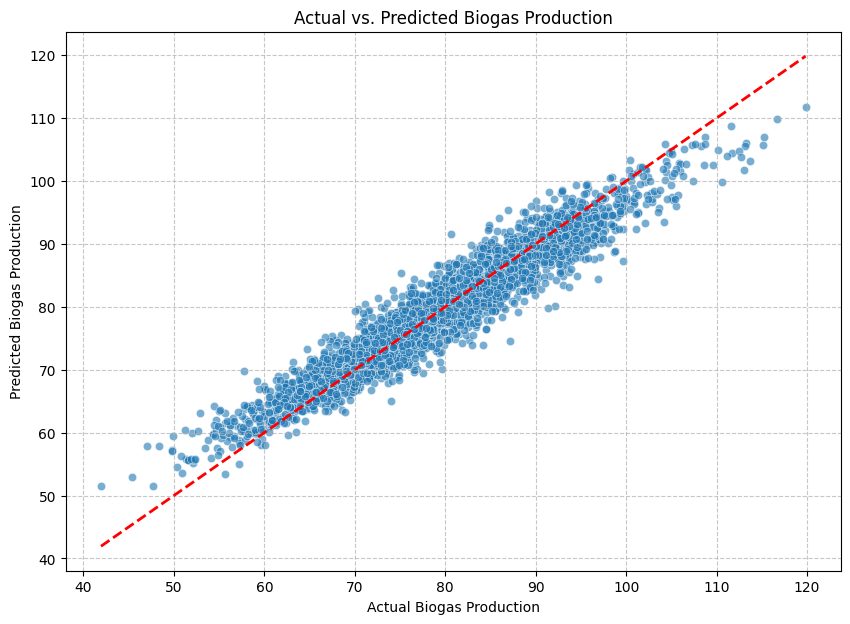

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45-degree line
plt.xlabel('Actual Biogas Production')
plt.ylabel('Predicted Biogas Production')
plt.title('Actual vs. Predicted Biogas Production')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()